# Sobel Edge Detection Tutorial Notebook

### Quick Vocab
* **Gradient**: the vector of partial derivatives of an image with respect to x and y, telling you the direction and magnitude of maximum intensity change at each pixel.
* **Vector**: A quantity with both magnitude and direction.
* **Derivative**: A measure of how fast something changes. A flat region will have a near 0 derivative and an edge with have a large one.
* **Partial Derivative (∂)**: a partial derivative measures change with respect to one variable at a time, holding the others fixed. So ∂f/∂x asks: "if I move only horizontally, how fast does intensity change?" And ∂f/∂y asks the same for vertical.
* **Kernel**: A small grid of weights
* **Convolution**: Sliding a small kernel over an image and at each position computing a weighted sum


In [ ]:
# Get image to test with
import requests

flower_image = 'https://hips.hearstapps.com/hmg-prod/images/sacred-lotus-gettyimages-1143403162-646fa5a441f5d.jpg?crop=0.535xw:1.00xh;0.0519xw,0'
response = requests.get(flower_image)

with open("flower.jpg", "wb") as f:
    f.write(response.content)

# Load Image into a Numpy Array

(3456, 2773, 3)


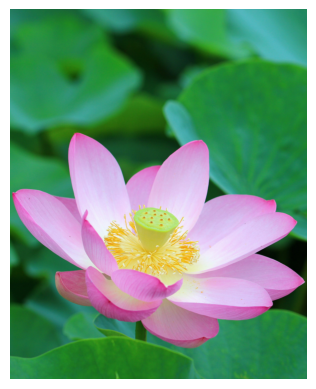

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# 1. Open the image
img = Image.open('flower.jpg')

# 2. Convert to numpy array
img_array = np.asarray(img)

# Check the shape (Height, Width, Channels - RGB)
print(img_array.shape)

plt.imshow(img_array)
plt.axis('off')
plt.show()

# Convert Image from RGB to Grayscale

(3456, 2773)


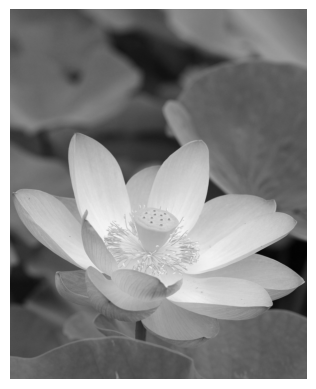

In [ ]:
# Don't forget that its Height then Width!
img_gscale = img_array[:, :, 0] * 0.299 + img_array[:, :, 1] * 0.587 + img_array[:, :, 2] * 0.114

# The : operator in numpy iterates through out the entire array
# The hardcoded values are set because humans percieve colors differently than raw weights
print(img_gscale.shape)
plt.imshow(img_gscale, cmap='gray')
plt.axis('off')
plt.show()

# Add a Gaussian Blur

* We will need to smooth the image slightly because sobel is super sensitive
* To do that we will use a convolution with the gaussian formula.

We are going to use a 3x3 kernel with a sigma of 1 and normalized.

In [ ]:
gaussian_kernel = np.array([[1, 2, 1],
                            [2, 4, 2],
                            [1, 2, 1]])

# Since its a 3x3 we need a way to handle the corners and edges. we can just pad the edges
img_padded = np.pad(img_gscale, 1, mode='constant', constant_values=0)

img_height = img_gscale.shape[0]
img_width = img_gscale.shape[1]

img_blur = np.zeros((img_height, img_width))

for h in range(img_height):
    for w in range(img_width):
        img_kernel = img_padded[h:h+3, w:w+3]
        img_blur[h,w] = np.sum(gaussian_kernel * img_kernel) * (1/16)

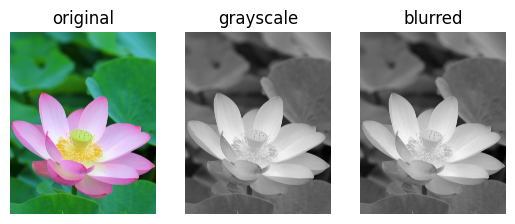

In [ ]:
fig, axes = plt.subplots(1, 3)
axes[0].imshow(img_array)
axes[0].set_title('original')
axes[1].imshow(img_gscale, cmap='gray')
axes[1].set_title('grayscale')
axes[2].imshow(img_blur, cmap='gray')
axes[2].set_title('blurred')

for ax in axes:
    ax.axis('off')

plt.show()

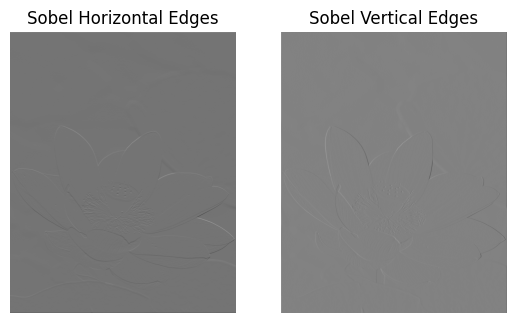

In [ ]:
sobel_along_y = np.array([[-1, -2, -1],
                           [0, 0, 0],
                           [1, 2, 1]])

sobel_along_x = np.array([[-1, 0, 1],
                          [-2, 0, 2],
                          [-1, 0, 1]])

# Craft blank images to write our edge values too
img_vert = np.zeros((img_height, img_width))
img_horiz = np.zeros((img_height, img_width))

# We have to pad the corners and edges again
img_padded = np.pad(img_blur, 1, mode='constant', constant_values=0)

img_height = img_blur.shape[0]
img_width = img_blur.shape[1]

# Iterate through every pixel
for h in range(img_height):
    for w in range(img_width):
        img_kernel = img_padded[h:h+3, w:w+3]
        img_vert[h,w] = np.sum(sobel_along_y * img_kernel)
        img_horiz[h,w] = np.sum(sobel_along_x * img_kernel)

# Show the results side by side
fig, axes = plt.subplots(1, 2)
axes[0].imshow(img_vert, cmap='gray')
axes[0].set_title('Sobel Horizontal Edges')
axes[1].imshow(img_horiz, cmap='gray')
axes[1].set_title('Sobel Vertical Edges')

for ax in axes:
    ax.axis('off')

plt.show()

There is a faint outline of our flower in there!
Lets combine both together to get the magnitude

(np.float64(-0.5), np.float64(2772.5), np.float64(3455.5), np.float64(-0.5))

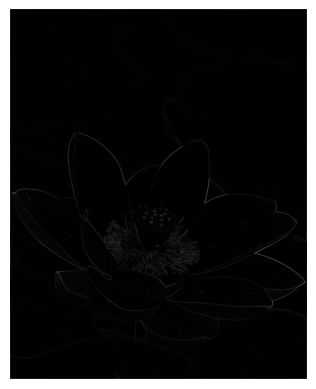

In [ ]:
img_magnitude = np.sqrt(img_horiz**2 + img_vert**2)
plt.imshow(img_magnitude, cmap='gray')
plt.axis('off')

(np.float64(-0.5), np.float64(2772.5), np.float64(3455.5), np.float64(-0.5))

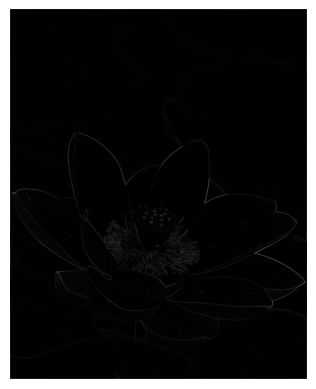

In [ ]:
img_norm = (img_magnitude - img_magnitude.min()) / (img_magnitude.max() - img_magnitude.min())
plt.imshow(img_norm, cmap='gray')
plt.axis('off')

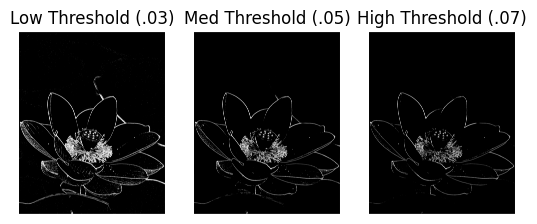

In [ ]:
img_edges_low = np.where(img_norm > .03, 1, 0)
img_edges_med = np.where(img_norm > .05, 1, 0)
img_edges_high = np.where(img_norm > .07, 1, 0)

fig, axes = plt.subplots(1, 3)
axes[0].imshow(img_edges_low, cmap='gray')
axes[0].set_title('Low Threshold (.03)')
axes[1].imshow(img_edges_med, cmap='gray')
axes[1].set_title('Med Threshold (.05)')
axes[2].imshow(img_edges_high, cmap='gray')
axes[2].set_title('High Threshold (.07)')

for ax in axes:
    ax.axis('off')

plt.show()

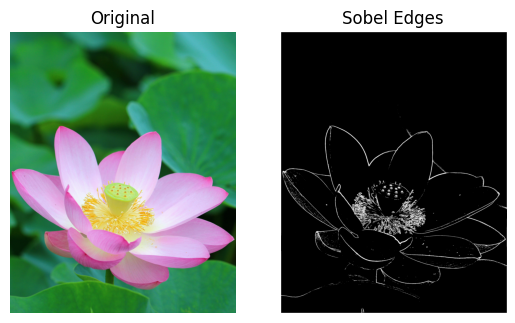

In [ ]:
fig, axes = plt.subplots(1, 2)
axes[0].imshow(img_array)
axes[0].set_title('Original')
axes[1].imshow(img_edges_med, cmap='gray')
axes[1].set_title('Sobel Edges')

for ax in axes:
    ax.axis('off')

plt.show()